In [1]:
import numpy as np
import pandas as pd

# Load data
data = np.load('data/bodmas.npz')
X = data['X']
y = data['y']
meta = pd.read_csv('data/bodmas_metadata.csv')

# Sanity checks
print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)
print("\nTop 20 families:")
print(meta['family'].value_counts().head(20))
print("\nUnique families:", meta['family'].nunique())
print("\nBenign vs Malware:")
print(meta['family'].isna().value_counts())

Feature matrix shape: (134435, 2381)
Labels shape: (134435,)

Top 20 families:
family
sfone          4729
wacatac        4694
upatre         3901
wabot          3673
small          3339
ganelp         2232
dinwod         2057
mira           1960
berbew         1749
sillyp2p       1616
ceeinject      1169
gepys          1124
benjamin       1071
musecador      1054
autoit          969
gandcrab        957
drolnux         920
smokeloader     868
unruy           865
qukart          823
Name: count, dtype: int64

Unique families: 582

Benign vs Malware:
family
True     77142
False    57293
Name: count, dtype: int64


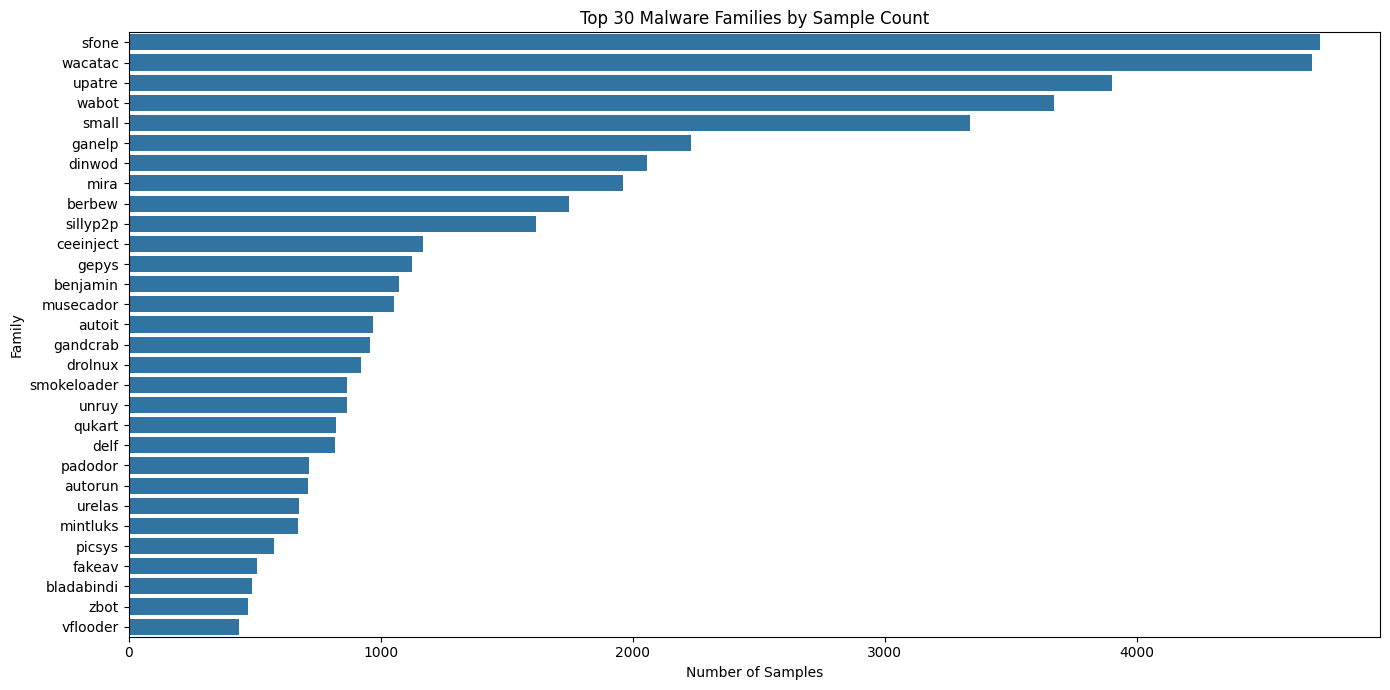

Families with < 100 samples: 525
Families with < 50 samples: 494
Families with >= 200 samples: 44


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 30 families by sample count
top30 = meta['family'].value_counts().head(30)

plt.figure(figsize=(14, 7))
sns.barplot(x=top30.values, y=top30.index)
plt.title("Top 30 Malware Families by Sample Count")
plt.xlabel("Number of Samples")
plt.ylabel("Family")
plt.tight_layout()
plt.savefig('results/class_distribution.png')
plt.show()

# How many families have less than 100 samples?
small_families = meta['family'].value_counts()
print(f"Families with < 100 samples: {(small_families < 100).sum()}")
print(f"Families with < 50 samples: {(small_families < 50).sum()}")
print(f"Families with >= 200 samples: {(small_families >= 200).sum()}")

In [3]:
# Filter to families with >= 200 samples
viable_families = meta['family'].value_counts()
viable_families = viable_families[viable_families >= 200]

print(f"Viable families: {len(viable_families)}")
print(f"Total samples in these families: {viable_families.sum()}")
print("\nAll viable families:")
print(viable_families)

Viable families: 44
Total samples in these families: 49970

All viable families:
family
sfone          4729
wacatac        4694
upatre         3901
wabot          3673
small          3339
ganelp         2232
dinwod         2057
mira           1960
berbew         1749
sillyp2p       1616
ceeinject      1169
gepys          1124
benjamin       1071
musecador      1054
autoit          969
gandcrab        957
drolnux         920
smokeloader     868
unruy           865
qukart          823
delf            817
padodor         715
autorun         712
urelas          677
mintluks        670
picsys          575
fakeav          509
bladabindi      491
zbot            473
vflooder        438
lunam           379
tofsee          362
sytro           319
fuerboos        311
mydoom          303
pykspa          303
agent           301
soltern         296
qqpass          292
blocker         285
ircbot          271
coinminer       249
salgorea        240
stormser        212
Name: count, dtype: int64


In [4]:
# Filter metadata to viable families only
meta_filtered = meta[meta['family'].isin(viable_families.index)].copy()

# Filter X and y to match
mask = meta['family'].isin(viable_families.index)
X_filtered = X[mask]
y_filtered = meta_filtered['family'].values

print(f"Filtered dataset shape: {X_filtered.shape}")
print(f"Labels shape: {y_filtered.shape}")

# Encode family labels as integers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y_filtered)

print(f"\nLabel range: {y_encoded.min()} to {y_encoded.max()}")
print(f"Number of classes: {len(le.classes_)}")
print(f"\nLabel mapping (first 10):")
for i, name in enumerate(le.classes_[:10]):
    print(f"  {i} → {name}")

Filtered dataset shape: (49970, 2381)
Labels shape: (49970,)

Label range: 0 to 43
Number of classes: 44

Label mapping (first 10):
  0 → agent
  1 → autoit
  2 → autorun
  3 → benjamin
  4 → berbew
  5 → bladabindi
  6 → blocker
  7 → ceeinject
  8 → coinminer
  9 → delf


In [5]:
from sklearn.model_selection import train_test_split

# 70% train, 15% val, 15% test — stratified by family
X_train, X_temp, y_train, y_temp = train_test_split(
    X_filtered, y_encoded, 
    test_size=0.30, 
    stratify=y_encoded, 
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    stratify=y_temp, 
    random_state=42
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")
print(f"Total: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} samples")

# Confirm stratification worked — check class distribution in train
import numpy as np
unique, counts = np.unique(y_train, return_counts=True)
print(f"\nMin samples per class in train: {counts.min()}")
print(f"Max samples per class in train: {counts.max()}")

Train: 34979 samples
Val:   7495 samples
Test:  7496 samples
Total: 49970 samples

Min samples per class in train: 148
Max samples per class in train: 3310


In [7]:
import os
import pickle

# Save processed data
with open('data/processed_data.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'label_encoder': le,
        'viable_families': viable_families
    }, f)

print("Saved to data/processed_data.pkl")
print(f"File size: {os.path.getsize('data/processed_data.pkl') / 1024 / 1024:.1f} MB")

Saved to data/processed_data.pkl
File size: 454.3 MB
